In [ ]:
# Classical Perceptron Training and Visualization
import torch
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 1. Prepare the dataset (AND gate)
x = torch.tensor([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=torch.float32)
y = torch.tensor([[0], [0], [0], [1]], dtype=torch.float32)

# X-OR gate
# x = torch.tensor([[0, 0],[0, 1],[1, 0],[1, 1]], dtype=torch.float32)
# y = torch.tensor([[0],[1],[1],[0]], dtype=torch.float32)

In [ ]:
# 2. Initialize weights and bias
weights = torch.zeros((2, 1), dtype=torch.float32)
bias = torch.tensor(0.0)
learning_rate = 1.0
epochs = 20

In [ ]:
# 3. Step activation function
def step_function(z):
    return (z >= 0).float()

In [ ]:
# 4. Training loop (classical perceptron)
for epoch in range(epochs):
    total_error = 0
    for i in range(len(x)):
        # Forward pass
        z = torch.matmul(x[i], weights) + bias
        y_pred = step_function(z).item()
        target = y[i].item()

        # Error
        error = target - y_pred
        total_error += abs(error)

        # Update weights and bias
        weights += learning_rate * error * x[i].reshape(-1, 1)
        bias += learning_rate * error

    print(f"Epoch {epoch+1}, Total Error: {total_error}")

    # Stop early if zero error
    if total_error == 0:
        print(f"Training converged at epoch {epoch+1}")
        break


print("Training finished.")
print("Final weights:", weights.numpy().flatten(), "Bias:", bias.item())



Epoch 1, Total Error: 2.0
Epoch 2, Total Error: 3.0
Epoch 3, Total Error: 3.0
Epoch 4, Total Error: 2.0
Epoch 5, Total Error: 1.0
Epoch 6, Total Error: 0.0
Training converged at epoch 6
Training finished.
Final weights: [2. 1.] Bias: -3.0


In [ ]:
# 5. Testing
print("\nTesting results:")
with torch.no_grad():
    predictions = step_function(torch.matmul(x, weights) + bias)
    print("Inputs:\n", x.numpy())
    print("Actual outputs:\n", y.numpy().flatten())
    print("Predicted outputs:\n", predictions.numpy().flatten())
    accuracy = (predictions == y).float().mean() * 100
    print(f"Accuracy: {accuracy.item():.2f}%")


Testing results:
Inputs:
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
Actual outputs:
 [0. 0. 0. 1.]
Predicted outputs:
 [0. 0. 0. 1.]
Accuracy: 100.00%


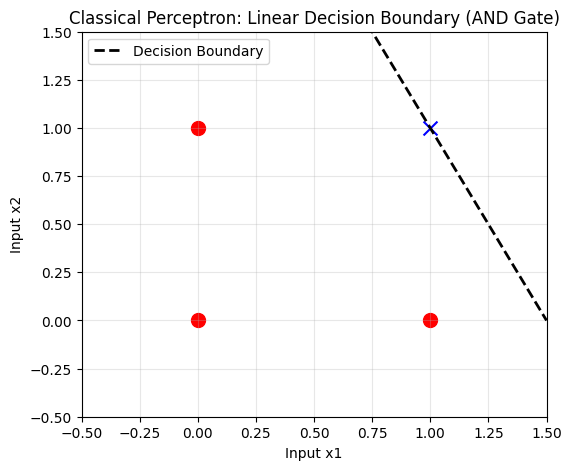

In [ ]:
# 6. Plotting the Decision Boundary
def plot_decision_boundary(weights, bias, x, y):
    w1, w2 = weights.numpy().flatten()
    b = bias.item()
    plt.figure(figsize=(6, 5))

    # Plot the data points
    for i in range(len(x)):
        color = 'blue' if y[i] == 1 else 'red'
        marker = 'x' if y[i] == 1 else 'o'
        plt.scatter(x[i, 0], x[i, 1], color=color, marker=marker, s=100)

    # Calculate decision boundary: w1*x1 + w2*x2 + b = 0
    x1_values = np.linspace(-0.5, 1.5, 100)
    if w2 != 0:  # avoid division by zero
        x2_values = -(w1 * x1_values + b) / w2
        plt.plot(x1_values, x2_values, 'k--', linewidth=2, label='Decision Boundary')

    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    plt.xlabel("Input x1")
    plt.ylabel("Input x2")
    plt.title("Classical Perceptron: Linear Decision Boundary (AND Gate)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Run the visualization
plot_decision_boundary(weights, bias, x, y)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def generate_evaluation_report(y_true, y_pred, labels=None):
    """
    Generates and displays a model evaluation report.
    """
    # 1. Generate textual classification report (Precision, Recall, F1)
    report_dict = classification_report(y_true, y_pred, target_names=labels, output_dict=True)
    report_df = pd.DataFrame(report_dict).transpose()

    print("--- Model Evaluation Report ---")
    print(f"Overall Accuracy: {accuracy_score(y_true, y_pred):.4f}\n")
    print("Detailed Metrics:")
    print(report_df)

    # 2. Generate and plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

# Example Usage
# y_true = [0, 1, 0, 1, 0, 1]
# y_pred = [0, 1, 0, 0, 0, 1]
# generate_evaluation_report(y_true, y_pred, labels=['Class A', 'Class B'])


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def generate_evaluation_report(y_true, y_pred, labels=None):
    """
    Generates and displays a model evaluation report.
    """
    # 1. Generate textual classification report (Precision, Recall, F1)
    report_dict = classification_report(y_true, y_pred, target_names=labels, output_dict=True)
    report_df = pd.DataFrame(report_dict).transpose()

    print("--- Model Evaluation Report ---")
    print(f"Overall Accuracy: {accuracy_score(y_true, y_pred):.4f}\n")
    print("Detailed Metrics:")
    print(report_df)

    # 2. Generate and plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def generate_evaluation_report(y_true, y_pred, labels=None):
    """
    Generates and displays a model evaluation report.
    """
    # 1. Generate textual classification report (Precision, Recall, F1)
    report_dict = classification_report(y_true, y_pred, target_names=labels, output_dict=True)
    report_df = pd.DataFrame(report_dict).transpose()

    print("--- Model Evaluation Report ---")
    print(f"Overall Accuracy: {accuracy_score(y_true, y_pred):.4f}\n")
    print("Detailed Metrics:")
    print(report_df)

    # 2. Generate and plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

## Classical Perceptron Evaluation Report

--- Model Evaluation Report ---
Overall Accuracy: 1.0000

Detailed Metrics:
              precision  recall  f1-score  support
0                   1.0     1.0       1.0      3.0
1                   1.0     1.0       1.0      1.0
accuracy            1.0     1.0       1.0      1.0
macro avg           1.0     1.0       1.0      4.0
weighted avg        1.0     1.0       1.0      4.0


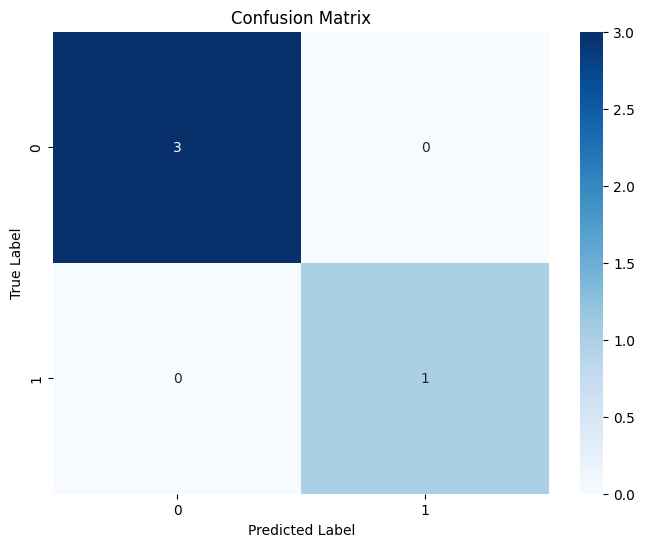

In [ ]:


y_true_classical = y.numpy().flatten()
y_pred_classical = predictions.numpy().flatten()

generate_evaluation_report(y_true_classical, y_pred_classical, labels=['0', '1'])

In [ ]:
#Perceptron Neural NW
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 1. Prepare the dataset (AND gate)

x = torch.tensor([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=torch.float32)
y = torch.tensor([[0], [0], [0], [1]], dtype=torch.float32)

# x = torch.tensor([[0, 0],[0, 1],[1, 0],[1, 1]], dtype=torch.float32)
# y = torch.tensor([[0],[1],[1],[0]], dtype=torch.float32)

In [ ]:
# 2. Define the Perceptron Model
model = nn.Sequential(
    nn.Linear(2, 1), # 2 input features, 1 output neuron
    nn.Sigmoid()     # Sigmoid activation function
)

In [ ]:
# 3. Define Loss Function and Optimizer
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

In [ ]:
# 4. Train the Model
for epoch in range(1000):

    # Forward pass: compute predicted y
    output = model(x)

    # Compute loss
    loss = criterion(output, y)

    # Backward pass:compute gradients
    optimizer.zero_grad() # Clear previous gradients
    loss.backward()       # Compute gradient of the loss

    # update weights and bias
    optimizer.step()

    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

print("Training finished.")

Epoch 0, Loss: 0.8624
Epoch 100, Loss: 0.5178
Epoch 200, Loss: 0.3939
Epoch 300, Loss: 0.3213
Epoch 400, Loss: 0.2732
Epoch 500, Loss: 0.2385
Epoch 600, Loss: 0.2121
Epoch 700, Loss: 0.1910
Epoch 800, Loss: 0.1738
Epoch 900, Loss: 0.1595
Training finished.


In [ ]:
# 5. Test the Model
with torch.no_grad(): # Disable gradient calculation for testing
    predictions = model(x)
    # Convert probabilities to binary output (0 or 1)
    predicted_classes = (predictions > 0.5).float()
    print("\n--- Test Results ---")
    print(f"Inputs:\n{x.numpy()}")
    print(f"Actual Outputs:\n{y.numpy().flatten()}")
    print(f"Predicted Outputs:\n{predicted_classes.numpy().flatten()}")

    # Calculate accuracy
    accuracy = (predicted_classes == y).float().mean() * 100
    print(f"Accuracy: {accuracy.item():.2f}%")


--- Test Results ---
Inputs:
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
Actual Outputs:
[0. 0. 0. 1.]
Predicted Outputs:
[0. 0. 0. 1.]
Accuracy: 100.00%


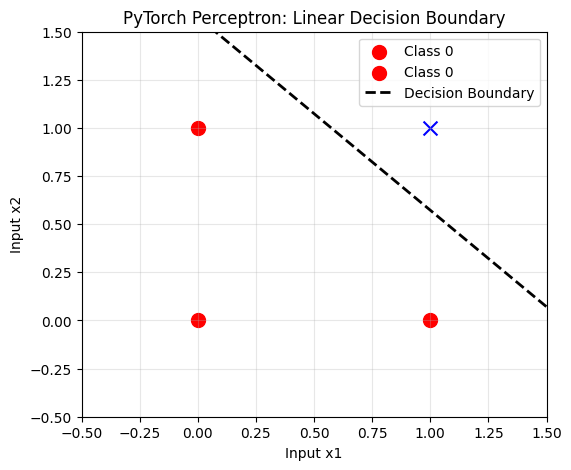

In [ ]:
# 6. Plotting the Linear Decision Boundary
def plot_decision_boundary(model, x, y):
    # Extract weights and bias from the trained PyTorch model
    # model[0] refers to the nn.Linear layer in your nn.Sequential
    w1, w2 = model[0].weight.data.numpy()[0]
    b = model[0].bias.data.numpy()[0]

    plt.figure(figsize=(6, 5))

    # 1. Plot the data points
    for i in range(len(x)):
        color = 'blue' if y[i] == 1 else 'red'
        marker = 'x' if y[i] == 1 else 'o'
        plt.scatter(x[i, 0], x[i, 1], color=color, marker=marker, s=100, label=f"Class {int(y[i])}" if i < 2 else "")

    # 2. Calculate the decision boundary line
    # Equation: w1*x1 + w2*x2 + b = 0  =>  x2 = -(w1*x1 + b) / w2
    x1_values = np.linspace(-0.5, 1.5, 100)
    x2_values = -(w1 * x1_values + b) / w2

    # 3. Draw the line
    plt.plot(x1_values, x2_values, color='black', linestyle='--', linewidth=2, label='Decision Boundary')

    # Formatting the plot
    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    plt.xlabel("Input x1")
    plt.ylabel("Input x2")
    plt.title("PyTorch Perceptron: Linear Decision Boundary")
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.show()

# Run the visualization
plot_decision_boundary(model, x, y)



## PyTorch Perceptron Evaluation Report

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def generate_evaluation_report(y_true, y_pred, labels=None):
    """
    Generates and displays a model evaluation report.
    """
    # 1. Generate textual classification report (Precision, Recall, F1)
    report_dict = classification_report(y_true, y_pred, target_names=labels, output_dict=True)
    report_df = pd.DataFrame(report_dict).transpose()

    print("--- Model Evaluation Report ---")
    print(f"Overall Accuracy: {accuracy_score(y_true, y_pred):.4f}\n")
    print("Detailed Metrics:")
    print(report_df)

    # 2. Generate and plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

# Example Usage
# y_true = [0, 1, 0, 1, 0, 1]
# y_pred = [0, 1, 0, 0, 0, 1]
# generate_evaluation_report(y_true, y_pred, labels=['Class A', 'Class B'])


--- Model Evaluation Report ---
Overall Accuracy: 1.0000

Detailed Metrics:
              precision  recall  f1-score  support
0                   1.0     1.0       1.0      3.0
1                   1.0     1.0       1.0      1.0
accuracy            1.0     1.0       1.0      1.0
macro avg           1.0     1.0       1.0      4.0
weighted avg        1.0     1.0       1.0      4.0


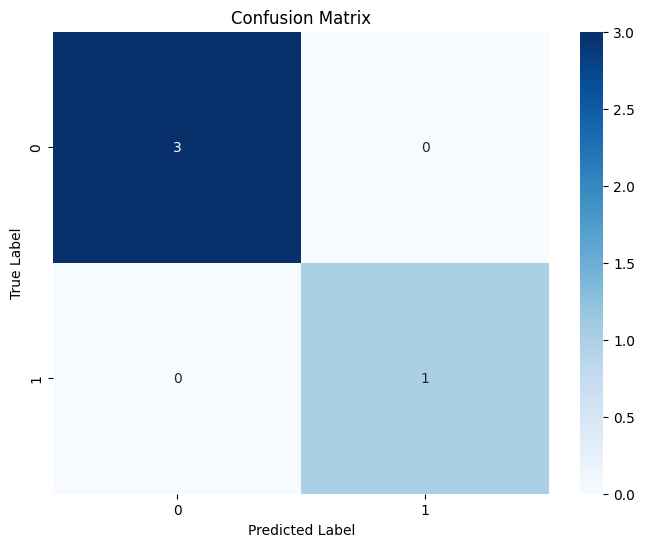

In [ ]:

y_true_pytorch = y.numpy().flatten()
y_pred_pytorch = predicted_classes.numpy().flatten()

generate_evaluation_report(y_true_pytorch, y_pred_pytorch, labels=['0', '1'])

# Single layer perceptron On Linear DAta (Kaggle )

In [ ]:
import pandas as pd
import torch

# 1. Load the CSV file into a pandas DataFrame
df_new_data = pd.read_csv('/content/single_layer_perceptron.csv')

# 2. Display the first few rows of df_new_data
print("DataFrame Head:")
print(df_new_data.head())

# 3. Display a concise summary of the DataFrame
print("\nDataFrame Info:")
df_new_data.info()

# 4. Separate features and target variable into NumPy arrays
X_new_np = df_new_data.iloc[:, :-1].values
y_new_np = df_new_data.iloc[:, -1].values

# 5. Convert X_new_np into a PyTorch tensor
x_new = torch.tensor(X_new_np, dtype=torch.float32)

# 6. Convert y_new_np into a PyTorch tensor and ensure it has a column dimension
y_new = torch.tensor(y_new_np, dtype=torch.float32).reshape(-1, 1)

print("\nx_new tensor shape:", x_new.shape)
print("y_new tensor shape:", y_new.shape)
print("x_new (first 5 rows):\n", x_new[:5])
print("y_new (first 5 rows):\n", y_new[:5])

DataFrame Head:
   Pattern  Feature1  Feature2  Feature3  Class_Label
0      1.0       1.0      0.08      0.72          1.0
1      2.0       1.0      0.10      1.00          1.0
2      3.0       1.0      0.26      0.58          1.0
3      4.0       1.0      0.35      0.95          0.0
4      5.0       1.0      0.45      0.15          1.0

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Pattern      13 non-null     float64
 1   Feature1     13 non-null     float64
 2   Feature2     13 non-null     float64
 3   Feature3     13 non-null     float64
 4   Class_Label  13 non-null     float64
dtypes: float64(5)
memory usage: 692.0 bytes

x_new tensor shape: torch.Size([14, 4])
y_new tensor shape: torch.Size([14, 1])
x_new (first 5 rows):
 tensor([[1.0000, 1.0000, 0.0800, 0.7200],
        [2.0000, 1.0000, 0.1000, 1.0000],
        [3.000

In [ ]:
import torch

# Identify rows with NaN values in y_new
# Assuming y_new is a 2D tensor where each row is a target
nan_mask = torch.isnan(y_new.flatten())

# Filter out rows with NaN values from both x_new and y_new
x_new_filtered = x_new[~nan_mask]
y_new_filtered = y_new[~nan_mask]

# Redefine x_new and y_new to use the filtered versions
x_new = x_new_filtered
y_new = y_new_filtered

print("Original x_new shape:", x_new_filtered.shape)
print("Original y_new shape:", y_new_filtered.shape)
print("NaN values removed from dataset.")

def step_function(z):
    return (z >= 0).float()

num_features_new = x_new.shape[1] # Determine the number of input features

# Initialize new weights and bias
weights_new = torch.zeros((num_features_new, 1), dtype=torch.float32)
bias_new = torch.tensor(0.0)
learning_rate_new = 1.0
epochs_new = 550

print("\n--- Training Classical Perceptron on New Data (Filtered) ---")

# Training loop for classical perceptron with new data
for epoch in range(epochs_new):
    total_error_new = 0
    for i in range(len(x_new)):
        # Forward pass
        z_new = torch.matmul(x_new[i], weights_new) + bias_new
        y_pred_new = step_function(z_new).item()
        target_new = y_new[i].item()

        # Error
        error_new = target_new - y_pred_new
        total_error_new += abs(error_new)

        # Update weights and bias
        weights_new += learning_rate_new * error_new * x_new[i].reshape(-1, 1)
        bias_new += learning_rate_new * error_new

    print(f"Epoch {epoch+1}, Total Error: {total_error_new}")

    # Stop early if zero error
    if total_error_new == 0:
        print(f"Training converged at epoch {epoch+1}")
        break

print("Training finished on new data.")
print("Final weights (new data):", weights_new.numpy().flatten(), "Bias (new data):", bias_new.item())


Original x_new shape: torch.Size([13, 4])
Original y_new shape: torch.Size([13, 1])
NaN values removed from dataset.

--- Training Classical Perceptron on New Data (Filtered) ---
Epoch 1, Total Error: 6.0
Epoch 2, Total Error: 5.0
Epoch 3, Total Error: 5.0
Epoch 4, Total Error: 6.0
Epoch 5, Total Error: 5.0
Epoch 6, Total Error: 6.0
Epoch 7, Total Error: 7.0
Epoch 8, Total Error: 7.0
Epoch 9, Total Error: 6.0
Epoch 10, Total Error: 7.0
Epoch 11, Total Error: 7.0
Epoch 12, Total Error: 6.0
Epoch 13, Total Error: 7.0
Epoch 14, Total Error: 7.0
Epoch 15, Total Error: 8.0
Epoch 16, Total Error: 7.0
Epoch 17, Total Error: 8.0
Epoch 18, Total Error: 7.0
Epoch 19, Total Error: 8.0
Epoch 20, Total Error: 7.0
Epoch 21, Total Error: 6.0
Epoch 22, Total Error: 7.0
Epoch 23, Total Error: 7.0
Epoch 24, Total Error: 8.0
Epoch 25, Total Error: 7.0
Epoch 26, Total Error: 8.0
Epoch 27, Total Error: 7.0
Epoch 28, Total Error: 8.0
Epoch 29, Total Error: 7.0
Epoch 30, Total Error: 8.0
Epoch 31, Total Erro


--- Testing Classical Perceptron on New Data ---
Inputs (first 5 rows):
 [[1.   1.   0.08 0.72]
 [2.   1.   0.1  1.  ]
 [3.   1.   0.26 0.58]
 [4.   1.   0.35 0.95]
 [5.   1.   0.45 0.15]]
Actual outputs (first 5 rows):
 [1. 1. 1. 0. 1.]
Predicted outputs (first 5 rows):
 [1. 0. 1. 0. 1.]
--- Model Evaluation Report ---
Overall Accuracy: 0.9231

Detailed Metrics:
              precision    recall  f1-score    support
0              0.857143  1.000000  0.923077   6.000000
1              1.000000  0.857143  0.923077   7.000000
accuracy       0.923077  0.923077  0.923077   0.923077
macro avg      0.928571  0.928571  0.923077  13.000000
weighted avg   0.934066  0.923077  0.923077  13.000000


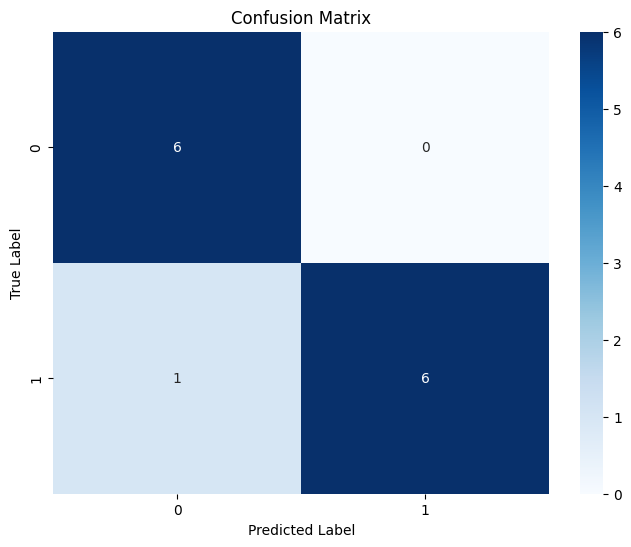

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def generate_evaluation_report(y_true, y_pred, labels=None):
    """
    Generates and displays a model evaluation report.
    """
    # 1. Generate textual classification report (Precision, Recall, F1)
    report_dict = classification_report(y_true, y_pred, target_names=labels, output_dict=True)
    report_df = pd.DataFrame(report_dict).transpose()

    print("--- Model Evaluation Report ---")
    print(f"Overall Accuracy: {accuracy_score(y_true, y_pred):.4f}\n")
    print("Detailed Metrics:")
    print(report_df)

    # 2. Generate and plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

print("\n--- Testing Classical Perceptron on New Data ---")
with torch.no_grad():
    predictions_new_classical = step_function(torch.matmul(x_new, weights_new) + bias_new)
    y_true_new_classical = y_new.numpy().flatten()
    y_pred_new_classical = predictions_new_classical.numpy().flatten()

    print("Inputs (first 5 rows):\n", x_new[:5].numpy())
    print("Actual outputs (first 5 rows):\n", y_true_new_classical[:5])
    print("Predicted outputs (first 5 rows):\n", y_pred_new_classical[:5])

    generate_evaluation_report(y_true_new_classical, y_pred_new_classical, labels=['0', '1'])